In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report
df = pd.read_csv('C:/Users/Unicom-7344/Desktop/Emiliano_Palacios/Uni 2/Aprendizaje Automatico/Titanic-Dataset.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

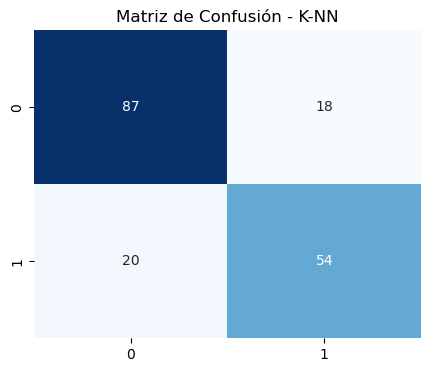

Métricas K-NN:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       105
           1       0.75      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [32]:

scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)
X_test_knn = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn, y_train)
y_pred_knn = knn.predict(X_test_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - K-NN')
plt.show()

print("Métricas K-NN:")
print(classification_report(y_test, y_pred_knn))

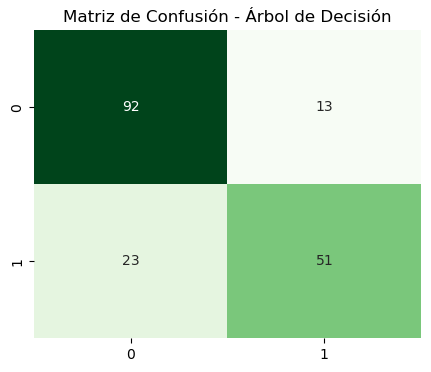

Métricas Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [33]:

arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

cm_arbol = confusion_matrix(y_test, y_pred_arbol)
plt.figure(figsize=(5,4))
sns.heatmap(cm_arbol, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

print("Métricas Árbol de Decisión:")
print(classification_report(y_test, y_pred_arbol))


